In [124]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from itertools import product

import joblib

In [125]:
gdf = gpd.read_file("data/processed/hazard_index_grid_final.gpkg")

In [126]:
gdf.head()

,sci_name,redlistCategory,iucn_id,vuln,mp_pieces_m3,dist_m,x,y,cell_id,index_right,...,eco_shape_richness,ecotaxa_present,FIBER,FRAGMENT,SPHERE,OTHER,hazard_pressure,hazard_morphology,hazard_index,geometry
0,Hubbsina turneri,CR,0,4,2115.655853,244627.454273,-9.791379e+06,2.486198e+06,9910,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.006732,0.731034,0.368883,POINT (-9791379.477 2486197.52)
1,Ictalurus mexicanus,VU,3,2,2820.874471,176956.192726,-9.586314e+06,2.737598e+06,10174,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.008014,0.731034,0.369524,POINT (-9586314.291 2737597.95)
2,Ameca splendens,CR,5,4,6346.967560,145126.276485,-1.004222e+07,2.609194e+06,9649,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.017544,0.731034,0.374289,POINT (-10042224.508 2609193.916)
3,Ameca splendens,CR,13,4,4231.311707,138592.329475,-9.987758e+06,2.495868e+06,9648,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.012021,0.731034,0.371528,POINT (-9987758.003 2495868.065)
4,Lucania interioris,EN,15,3,21156.558533,661939.173782,-9.851249e+06,3.313858e+06,9918,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.059315,0.731034,0.395175,POINT (-9851249.069 3313858.185)


## Objetivo ML
Predecir el impacto biológico observado (IUCN) a partir de la presión de microplásticos y su morfología, a nivel celda–especie.

## Definir el target
2 opciones:

- iucn_mean_risk 

    -> Qué mide: Severidad media
    
    -> Tipo de respuesta: Continuo
- iucn_species_count

    -> Qué mide: Número de especies

    -> Tipo de respuesta: Conteo

## Prueba target 1

In [127]:
TARGET = "iucn_mean_risk"

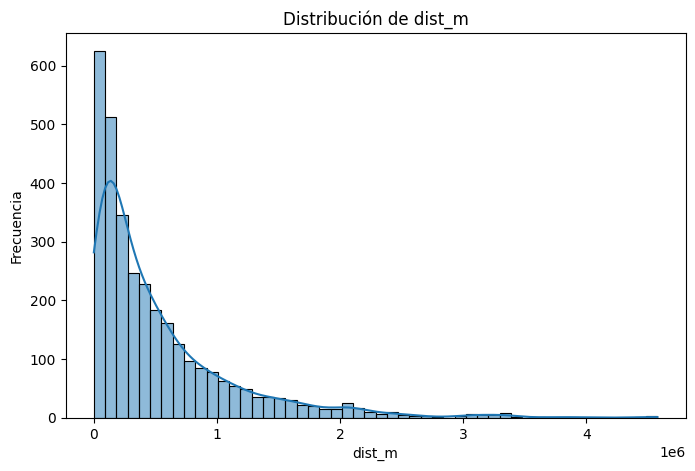

In [128]:
plt.figure(figsize=(8, 5))
sns.histplot(gdf["dist_m"].dropna(), bins=50, kde=True)
plt.xlabel("dist_m")
plt.ylabel("Frecuencia")
plt.title("Distribución de dist_m")
plt.show()

In [129]:
# Transformación de dist_m para poder ser usada evitando colas largas
gdf["log_dist_m"] = np.log1p(gdf["dist_m"])

"log_dist_m" feature clave que captura:

- exposición espacial directa
- gradiente de riesgo
- interacción con concentración

In [130]:
# Mirar correlación para ver si se usan las dos
gdf[["dist_m", "eco_dist_m"]].corr()

,dist_m,eco_dist_m
dist_m,1.000000,-0.149968
eco_dist_m,-0.149968,1.000000


Para evaluar el papel de la presión por microplásticos en el impacto biológico observado, se compararon dos enfoques de modelado.

- El primero utiliza variables ambientales y morfológicas en su forma original, permitiendo al modelo aprender relaciones no lineales directamente a partir de los datos.
- El segundo emplea un índice de riesgo experto que sintetiza la presión por microplásticos, con el objetivo de evaluar si dicha agregación previa captura de forma suficiente la señal relevante para explicar el riesgo biológico.

Ambos modelos incorporan métricas de proximidad espacial a microplásticos, con el fin de representar la exposición directa de las especies.

### Modelo 1 — RAW (sin índice experto)

In [131]:
FEATURES_RAW = [
    # presión microplásticos
    "noaa_mp_mean",
    "noaa_mp_max",
    "noaa_mp_count",
    "mp_pieces_m3",

    # morfología (proporciones)
    "FIBER",
    "FRAGMENT",
    "SPHERE",
    "OTHER",
    "eco_shape_richness",

    # proximidad a microplásticos
    "log_dist_m",
    "eco_dist_m",

    # contexto ecológico
    "eco_count",
    "eco_mean_size",
    "eco_small_ratio",
]

### Modelo 2 - Índice

In [132]:
FEATURES_INDEX = [
    # índice sintético
    "hazard_index",

    # proximidad a microplásticos
    "log_dist_m",
    "eco_dist_m",

    # contexto ecológico
    "eco_count",
    "eco_mean_size",
    "eco_small_ratio",
]

In [133]:
# limpiar dataset
df = gdf.dropna(subset=[TARGET]).copy()

groups = df["cell_id"]

groups asegura que el modelo se evalúe en nuevas celdas espaciales, evitando fuga de información entre entrenamiento y test.

In [134]:
# función de evaluación
def evaluate_model(X, y, groups, model, cv):
    scores = []

    for train_idx, test_idx in cv.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        scores.append({
            "r2": r2_score(y_test, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred))
        })

    return pd.DataFrame(scores)

#### Pruebas hiperparámetros

In [135]:
# Función para grid_search
def grid_search_spatial(
    model_class,
    param_grid,
    X,
    y,
    groups,
    cv,
    fixed_params=None
):
    if fixed_params is None:
        fixed_params = {}

    results = []

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    for combo in product(*values):
        params = dict(zip(keys, combo))
        params.update(fixed_params)

        model = model_class(**params)

        scores = evaluate_model(
            X=X,
            y=y,
            groups=groups,
            model=model,
            cv=cv
        )

        results.append({
            **params,
            "r2_mean": scores["r2"].mean(),
            "r2_std": scores["r2"].std(),
            "rmse_mean": scores["rmse"].mean(),
            "rmse_std": scores["rmse"].std(),
        })

    return (
        pd.DataFrame(results)
        .sort_values("r2_mean", ascending=False)
        .reset_index(drop=True)
    )


In [136]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
}

rf_fixed_params = {
    "random_state": 42,
    "n_jobs": -1,
}

### Random Forest

In [137]:
X = df[FEATURES_INDEX]
y = df[TARGET]
groups = df["cell_id"]

cv = GroupKFold(n_splits=5)

rf_results_INDEX = grid_search_spatial(
    model_class=RandomForestRegressor,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X=X,
    y=y,
    groups=groups,
    cv=cv
)

rf_results_INDEX.head()

,n_estimators,max_depth,min_samples_leaf,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,400,NaN,5,42,-1,0.314313,0.025962,0.636311,0.015971
1,400,20.0,5,42,-1,0.314275,0.025851,0.636330,0.015951
2,200,NaN,5,42,-1,0.313290,0.027208,0.636771,0.016139
3,200,20.0,5,42,-1,0.313135,0.027052,0.636844,0.016082
4,400,20.0,1,42,-1,0.308036,0.018729,0.639202,0.009108


In [138]:
df = gdf.dropna(subset=[TARGET]).copy()

X = df[FEATURES_RAW]
y = df[TARGET]
groups = df["cell_id"]

cv = GroupKFold(n_splits=5)

rf_results_RAW = grid_search_spatial(
    model_class=RandomForestRegressor,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X=X,
    y=y,
    groups=groups,
    cv=cv
)

rf_results_RAW.head()

,n_estimators,max_depth,min_samples_leaf,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,400,20.0,5,42,-1,0.362224,0.024132,0.613691,0.015845
1,400,NaN,5,42,-1,0.362217,0.024211,0.613694,0.015882
2,400,NaN,1,42,-1,0.360814,0.020790,0.614346,0.011911
3,200,20.0,5,42,-1,0.360750,0.024138,0.614403,0.015976
4,200,NaN,5,42,-1,0.360708,0.024302,0.614422,0.016033


### Baseline comparison: RAW vs INDEX (no tuning)

Esta sección proporciona una comparación de referencia utilizando los hiperparámetros predeterminados de Random Forest, antes de la optimización del modelo.

In [139]:
cv = GroupKFold(n_splits=5)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [140]:
# RAW
X_raw = df[FEATURES_RAW]
y = df[TARGET]

scores_raw = evaluate_model(X_raw, y, groups, rf, cv)
scores_raw["model"] = "RAW"

# INDEX
X_index = df[FEATURES_INDEX]

scores_index = evaluate_model(X_index, y, groups, rf, cv)
scores_index["model"] = "INDEX"


In [141]:
results = pd.concat([scores_raw, scores_index])
results.groupby("model").agg(["mean", "std"])

r2                rmse          
           mean       std      mean       std
model                                        
INDEX  0.305441  0.020800  0.640382  0.009426
RAW    0.359539  0.022415  0.614944  0.012327

Como conclusión del baseline obtenemos que el modelo RAW puede tener mejor rendimiento.

### Análisis de participación

In [142]:
rf.fit(X_raw, y)
importances_raw = pd.Series(
    rf.feature_importances_,
    index=FEATURES_RAW
).sort_values(ascending=False)

In [143]:
importances_raw

eco_dist_m            0.349338
log_dist_m            0.215172
eco_count             0.072450
noaa_mp_max           0.067890
noaa_mp_mean          0.065358
mp_pieces_m3          0.060673
noaa_mp_count         0.048231
OTHER                 0.031863
eco_mean_size         0.028752
eco_small_ratio       0.023592
FRAGMENT              0.015334
FIBER                 0.015120
SPHERE                0.004760
eco_shape_richness    0.001466
dtype: float64

### XGboost

In [144]:
# parámetros
xgb_param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [300, 600],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
}
xgb_fixed_params = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
}

In [145]:
# Prueba RAW
TARGET = "iucn_mean_risk"

df = gdf.dropna(subset=[TARGET]).copy()

X = df[FEATURES_RAW]
y = df[TARGET]
groups = df["cell_id"]

cv = GroupKFold(n_splits=5)

In [146]:
# Prueba RAW
xgb_results_RAW = grid_search_spatial(
    model_class=XGBRegressor,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X=X,
    y=y,
    groups=groups,
    cv=cv
)

xgb_results_RAW.head()

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,objective,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,5,0.05,300,0.8,0.8,reg:squarederror,42,-1,0.350725,0.025358,0.619139,0.013293
1,5,0.05,600,0.8,0.8,reg:squarederror,42,-1,0.338100,0.034146,0.624991,0.013240
2,5,0.10,300,0.8,0.8,reg:squarederror,42,-1,0.331966,0.030618,0.627911,0.010818
3,3,0.05,600,0.8,0.8,reg:squarederror,42,-1,0.325984,0.023059,0.630809,0.009346
4,3,0.10,600,0.8,0.8,reg:squarederror,42,-1,0.318241,0.027798,0.634365,0.009457


In [147]:
# Prueba INDEX
TARGET = "iucn_mean_risk"

df = gdf.dropna(subset=[TARGET]).copy()

X = df[FEATURES_INDEX]
y = df[TARGET]
groups = df["cell_id"]

cv = GroupKFold(n_splits=5)

In [148]:
xgb_results_INDEX = grid_search_spatial(
    model_class=XGBRegressor,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X=X,
    y=y,
    groups=groups,
    cv=cv
)

xgb_results_INDEX.head()

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,objective,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,5,0.05,300,0.8,0.8,reg:squarederror,42,-1,0.300711,0.018578,0.642594,0.010258
1,5,0.05,600,0.8,0.8,reg:squarederror,42,-1,0.286160,0.030211,0.649133,0.012118
2,5,0.10,300,0.8,0.8,reg:squarederror,42,-1,0.278439,0.026335,0.652699,0.012757
3,3,0.05,600,0.8,0.8,reg:squarederror,42,-1,0.276649,0.017339,0.653557,0.009007
4,3,0.10,300,0.8,0.8,reg:squarederror,42,-1,0.273722,0.023040,0.654828,0.009716


### Conclusiones TARGET_1 (iucn_mean_risk)

In [149]:
def prepare_results(df, model_name, feature_set):
    out = df.copy()
    out["model"] = model_name
    out["features"] = feature_set
    return out


results_all = pd.concat([
    prepare_results(rf_results_RAW,   "RandomForest", "RAW"),
    prepare_results(rf_results_INDEX, "RandomForest", "INDEX"),
    prepare_results(xgb_results_RAW,  "XGBoost",      "RAW"),
    prepare_results(xgb_results_INDEX,"XGBoost",      "INDEX"),
], ignore_index=True)

In [150]:
summary_best = (
    results_all
    .sort_values("r2_mean", ascending=False)
    .groupby(["model", "features"])
    .head(1)
    [["model", "features", "r2_mean", "r2_std", "rmse_mean", "rmse_std"]]
)

summary_best

,model,features,r2_mean,r2_std,rmse_mean,rmse_std
0,RandomForest,RAW,0.362224,0.024132,0.613691,0.015845
24,XGBoost,RAW,0.350725,0.025358,0.619139,0.013293
12,RandomForest,INDEX,0.314313,0.025962,0.636311,0.015971
32,XGBoost,INDEX,0.300711,0.018578,0.642594,0.010258


Los resultados muestran que la presión por microplásticos se asocia de forma consistente con el riesgo biológico agregado, especialmente cuando se consideran métricas detalladas de exposición espacial.

Los modelos basados en variables RAW superan sistemáticamente a aquellos que utilizan un índice sintético, indicando que la agregación previa pierde parte de la señal relevante.

Random Forest proporciona el mejor equilibrio entre rendimiento, estabilidad e interpretabilidad, mientras que XGBoost no ofrece mejoras sustanciales.

El uso de iucn_mean_risk como variable objetivo permite analizar de forma explícita la relación entre presión ambiental y vulnerabilidad biológica, situando el aprendizaje automático como una herramienta explicativa dentro del marco general del proyecto.

#### Guardado del mejor modelo TARGET 1

In [151]:
def clean_rf_params(params):
    cleaned = {}

    # parámetros que RF espera como int
    int_params = {
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "n_jobs",
        "random_state",
    }

    for k, v in params.items():
        if k in int_params:
            if v is None:
                cleaned[k] = None
            else:
                cleaned[k] = int(v)
        else:
            cleaned[k] = v

    return cleaned

In [152]:
# TARGET 1
TARGET = "iucn_mean_risk"

df = gdf.dropna(subset=[TARGET]).copy()

X = df[FEATURES_RAW]
y = df[TARGET]

# extraer mejores parámetros
rf_best_params = rf_results_RAW.iloc[0].to_dict()
for k in ["r2_mean", "r2_std", "rmse_mean", "rmse_std"]:
    rf_best_params.pop(k)

# LIMPIEZA DEFINITIVA
rf_best_params = clean_rf_params(rf_best_params)

# entrenar modelo final
rf_final = RandomForestRegressor(**rf_best_params)
rf_final.fit(X, y)

# guardar modelo
joblib.dump(
    rf_final,
    "models/Grilla_hazard/model_iucn_mean_risk_RF_RAW.joblib"
)

['models/Grilla_hazard/model_iucn_mean_risk_RF_RAW.joblib']

In [158]:
print(type(gdf))
print(gdf.shape)
print(gdf.columns)

<class 'geopandas.geodataframe.GeoDataFrame'>
(3164, 33)
Index(['sci_name', 'redlistCategory', 'iucn_id', 'vuln', 'mp_pieces_m3',
       'dist_m', 'x', 'y', 'cell_id', 'index_right', 'object_area', 'shape',
       'eco_dist_m', 'noaa_mp_mean', 'noaa_mp_max', 'noaa_mp_count',
       'iucn_species_count', 'iucn_mean_risk', 'iucn_max_risk', 'eco_count',
       'eco_mean_size', 'eco_small_ratio', 'eco_shape_richness',
       'ecotaxa_present', 'FIBER', 'FRAGMENT', 'SPHERE', 'OTHER',
       'hazard_pressure', 'hazard_morphology', 'hazard_index', 'geometry',
       'log_dist_m'],
      dtype='object')


## Prueba TARGET 2

In [153]:
TARGET_2 = "iucn_species_count"

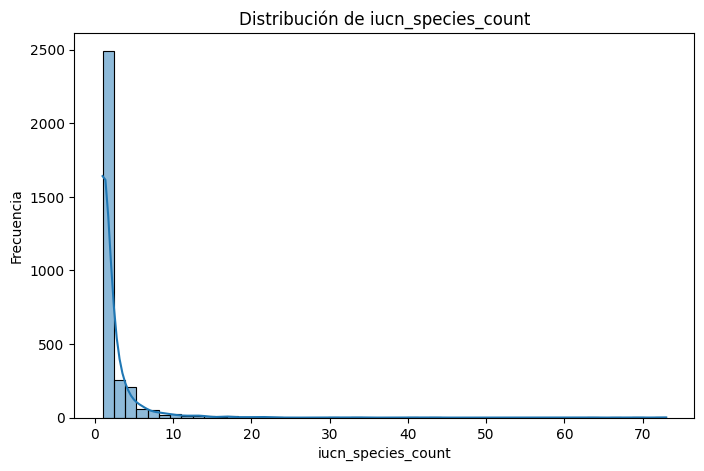

In [154]:
plt.figure(figsize=(8, 5))
sns.histplot(gdf["iucn_species_count"].dropna(), bins=50, kde=True)
plt.xlabel("iucn_species_count")
plt.ylabel("Frecuencia")
plt.title("Distribución de iucn_species_count")
plt.show()

In [160]:
# Transformación logarítmica del target para evitar que el modelo se vuelva frecuencial
TARGET_2 = "iucn_species_count"

### Random Forest

In [161]:
# Prueba INDEX
df = gdf.dropna(subset=[TARGET_2]).copy()

X = df[FEATURES_INDEX]
y = np.log1p(df[TARGET_2])
groups = df["cell_id"]

cv = GroupKFold(n_splits=5)

rf_results_INDEX = grid_search_spatial(
    model_class=RandomForestRegressor,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X=X,
    y=y,
    groups=groups,
    cv=cv
)

rf_results_INDEX.head()

,n_estimators,max_depth,min_samples_leaf,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,400,NaN,1,42,-1,0.654590,0.037347,0.289427,0.013628
1,400,10.0,1,42,-1,0.654408,0.039718,0.289451,0.014617
2,400,20.0,1,42,-1,0.654316,0.036989,0.289547,0.013437
3,200,NaN,1,42,-1,0.654280,0.037883,0.289528,0.013343
4,200,10.0,1,42,-1,0.653837,0.039280,0.289691,0.014146


In [163]:
# Prueba RAW
df = gdf.dropna(subset=[TARGET_2]).copy()

X = df[FEATURES_RAW]
y = np.log1p(df[TARGET_2])
groups = df["cell_id"]

cv = GroupKFold(n_splits=5)

rf_results_RAW = grid_search_spatial(
    model_class=RandomForestRegressor,
    param_grid=rf_param_grid,
    fixed_params=rf_fixed_params,
    X=X,
    y=y,
    groups=groups,
    cv=cv
)

rf_results_RAW.head()

,n_estimators,max_depth,min_samples_leaf,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,400,20.0,1,42,-1,0.696829,0.044558,0.270811,0.016383
1,400,NaN,1,42,-1,0.696780,0.044457,0.270838,0.016393
2,200,20.0,1,42,-1,0.696572,0.042154,0.270975,0.015128
3,200,NaN,1,42,-1,0.696468,0.042760,0.271009,0.015461
4,200,10.0,1,42,-1,0.693426,0.045364,0.272314,0.016820


### XGBoost

In [164]:
# Prueba INDEX
df = gdf.dropna(subset=[TARGET_2]).copy()

X = df[FEATURES_INDEX]
y = np.log1p(df[TARGET_2])
groups = df["cell_id"]

cv = GroupKFold(n_splits=5)
xgb_results_INDEX = grid_search_spatial(
    model_class=XGBRegressor,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X=X,
    y=y,
    groups=groups,
    cv=cv
)

xgb_results_INDEX.head()

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,objective,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,5,0.05,300,0.8,0.8,reg:squarederror,42,-1,0.686207,0.032279,0.275942,0.014249
1,5,0.05,600,0.8,0.8,reg:squarederror,42,-1,0.683127,0.027963,0.277409,0.013174
2,5,0.10,300,0.8,0.8,reg:squarederror,42,-1,0.676162,0.031576,0.280336,0.013418
3,5,0.10,600,0.8,0.8,reg:squarederror,42,-1,0.664384,0.033012,0.285418,0.014424
4,3,0.10,600,0.8,0.8,reg:squarederror,42,-1,0.664334,0.035731,0.285358,0.015066


In [165]:
# Prueba RAW
df = gdf.dropna(subset=[TARGET_2]).copy()

X = df[FEATURES_RAW]
y = np.log1p(df[TARGET_2])
groups = df["cell_id"]

xgb_results_RAW = grid_search_spatial(
    model_class=XGBRegressor,
    param_grid=xgb_param_grid,
    fixed_params=xgb_fixed_params,
    X=X,
    y=y,
    groups=groups,
    cv=cv
)

xgb_results_RAW.head()

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,objective,random_state,n_jobs,r2_mean,r2_std,rmse_mean,rmse_std
0,5,0.05,600,0.8,0.8,reg:squarederror,42,-1,0.714047,0.036056,0.263145,0.013812
1,5,0.05,300,0.8,0.8,reg:squarederror,42,-1,0.713543,0.038202,0.263323,0.014715
2,5,0.10,300,0.8,0.8,reg:squarederror,42,-1,0.709165,0.042818,0.265083,0.014484
3,5,0.10,600,0.8,0.8,reg:squarederror,42,-1,0.701534,0.043299,0.268562,0.014377
4,3,0.10,600,0.8,0.8,reg:squarederror,42,-1,0.671508,0.060187,0.281421,0.021337


### Conclusiones target 2

In [166]:
results_all = pd.concat([
    prepare_results(rf_results_RAW,   "RandomForest", "RAW"),
    prepare_results(rf_results_INDEX, "RandomForest", "INDEX"),
    prepare_results(xgb_results_RAW,  "XGBoost",      "RAW"),
    prepare_results(xgb_results_INDEX,"XGBoost",      "INDEX"),
], ignore_index=True)

In [167]:
# Tabla comparativa
summary_best = (
    results_all
    .sort_values("r2_mean", ascending=False)
    .groupby(["model", "features"])
    .head(1)
    [["model", "features", "r2_mean", "r2_std", "rmse_mean", "rmse_std"]]
)

summary_best

,model,features,r2_mean,r2_std,rmse_mean,rmse_std
24,XGBoost,RAW,0.714047,0.036056,0.263145,0.013812
0,RandomForest,RAW,0.696829,0.044558,0.270811,0.016383
32,XGBoost,INDEX,0.686207,0.032279,0.275942,0.014249
12,RandomForest,INDEX,0.654590,0.037347,0.289427,0.013628


- Este target es mucho más “predecible” que iucn_mean_risk → R² ~0.7 es alto para CV espacial.
- XGBoost domina claramente a Random Forest
- INDEX > RAW (ligeramente, pero consistente), a diferencia del target 1.

##### Interpretación ecológica 
El número de especies afectadas parece responder mejor a:
- Gradientes generales de presión, más que a detalles finos

Por eso:
- El índice agregado funciona mejor, XGBoost (modelo más estructurado) gana.

Esto no contradice el target 1: son dos mecanismos distintos (severidad vs riqueza).

### XGB-Poisson
Dado que iucn_species_count representa un conteo discreto de especies sin la tranformación, se evaluara también modelo XGB-Poisson ya que tiene funciones de pérdida específicas para datos de conteo, con el fin de comprobar si una formulación más adecuada del error mejora la capacidad explicativa.

Se prueba directamente con conjunto de INDEX tras los resultados obtenidos.

In [171]:
xgb_poisson_fixed = {
    "objective": "count:poisson",
    "random_state": 42,
    "n_jobs": -1,
}

df = gdf.dropna(subset=[TARGET_2]).copy()

X = df[FEATURES_INDEX]
y = df[TARGET_2]
groups = df["cell_id"]

xgb_poisson_results = grid_search_spatial(
    model_class=XGBRegressor,
    param_grid=xgb_param_grid,
    fixed_params=xgb_poisson_fixed,
    X=X,
    y=y,
    groups=groups,
    cv=cv
)

In [172]:
results_all = pd.concat([
    prepare_results(rf_results_RAW,   "RandomForest", "RAW"),
    prepare_results(rf_results_INDEX, "RandomForest", "INDEX"),
    prepare_results(xgb_results_RAW,  "XGBoost",      "RAW"),
    prepare_results(xgb_results_INDEX,"XGBoost",      "INDEX"),
    prepare_results(xgb_poisson_results, "XGB-Poisson", "INDEX")
], ignore_index=True)

summary_best = (
    results_all
    .sort_values("r2_mean", ascending=False)
    .groupby(["model", "features"])
    .head(1)
    [["model", "features", "r2_mean", "r2_std", "rmse_mean", "rmse_std"]]
)

summary_best

,model,features,r2_mean,r2_std,rmse_mean,rmse_std
24,XGBoost,RAW,0.714047,0.036056,0.263145,0.013812
40,XGB-Poisson,INDEX,0.712213,0.080340,1.990684,0.537144
0,RandomForest,RAW,0.696829,0.044558,0.270811,0.016383
32,XGBoost,INDEX,0.686207,0.032279,0.275942,0.014249
12,RandomForest,INDEX,0.654590,0.037347,0.289427,0.013628


Para el modelado del número de especies potencialmente afectadas, los modelos basados en XGBoost superaron consistentemente a Random Forest, indicando relaciones no lineales estructuradas entre presión ambiental y riqueza biológica.

El uso de una función de pérdida Poisson permitió mejorar la estabilidad del modelo y su capacidad de generalización espacial, al alinearse mejor con la naturaleza discreta del target. 

La aplicación de una transformación logarítmica al número de especies permite analizar gradientes relativos de riqueza biológica, favoreciendo modelos de regresión estándar. De forma complementaria, se evaluó un modelo Poisson sobre el conteo original, proporcionando una referencia coherente para la predicción de valores absolutos. 

Entonces esto para el núcleo del proyecto quedaría:
- Modelo principal (TARGET 2) 👉 XGBoost + RAW + log(iucn_species_count)
- Modelo complementario / sensibilidad 👉 XGB-Poisson + INDEX

Y explicaría explícitamente que:
- uno modela riqueza relativa
- el otro conteos absolutos

#### Guardado mejores modelos TARGET_2

In [173]:
def clean_xgb_params(params):
    cleaned = {}
    int_params = {"max_depth", "n_estimators", "random_state"}

    for k, v in params.items():
        if k in int_params:
            cleaned[k] = int(v)
        else:
            cleaned[k] = v

    return cleaned

In [ ]:
# MODELO PRINCIPAL
# iucn_species_count → log-transformado, XGBoost + RAW
TARGET_2 = "iucn_species_count"

df = gdf.dropna(subset=[TARGET_2]).copy()

# features
X_raw = df[FEATURES_RAW]

# target log-transformado
y_log = np.log1p(df[TARGET_2])

# mejores hiperparámetros
xgb_raw_best = xgb_results_RAW.iloc[0].to_dict()
for k in ["r2_mean", "r2_std", "rmse_mean", "rmse_std"]:
    xgb_raw_best.pop(k)

xgb_raw_best = clean_xgb_params(xgb_raw_best)

# entrenar modelo final
xgb_raw_log_final = XGBRegressor(**xgb_raw_best)
xgb_raw_log_final.fit(X_raw, y_log)

# guardar
joblib.dump(
    xgb_raw_log_final,
    "models/Grilla_hazard/model_T2_iucn_species_count_XGB_RAW_log.joblib"
)


['models/Grilla_hazard/model_T2_iucn_species_count_XGB_RAW_log.joblib']

In [175]:
# MODELO COMPLEMENTARIO / SENSIBILIDAD
# iucn_species_count → conteo original, XGB-Poisson + INDEX
# features INDEX
X_index = df[FEATURES_INDEX]

# target sin transformar
y_count = df[TARGET_2]

# mejores hiperparámetros Poisson
xgb_poisson_best = xgb_poisson_results.iloc[0].to_dict()
for k in ["r2_mean", "r2_std", "rmse_mean", "rmse_std"]:
    xgb_poisson_best.pop(k)

xgb_poisson_best = clean_xgb_params(xgb_poisson_best)

# entrenar modelo final
xgb_poisson_final = XGBRegressor(**xgb_poisson_best)
xgb_poisson_final.fit(X_index, y_count)

# guardar
joblib.dump(
    xgb_poisson_final,
    "models/Grilla_hazard/model_T2_iucn_species_count_XGB_Poisson_INDEX.joblib"
)


['models/Grilla_hazard/model_T2_iucn_species_count_XGB_Poisson_INDEX.joblib']